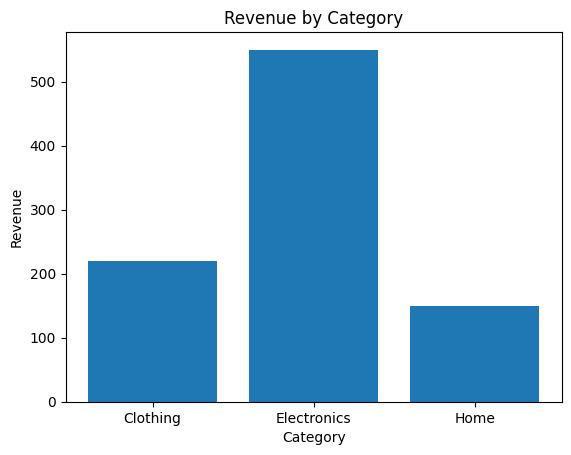

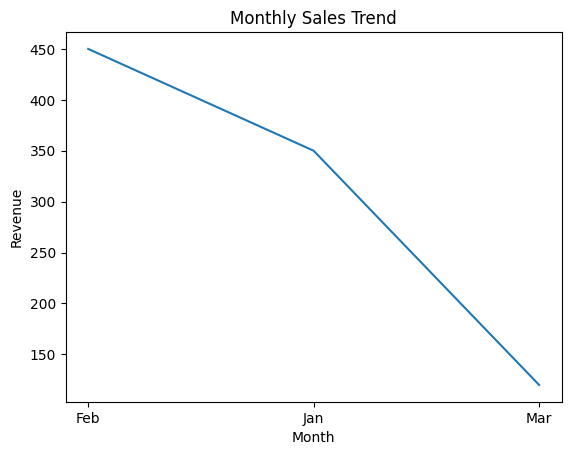


KPI:
   total_revenue  avg_order
0            920      184.0

INSIGHTS:
- Electronics is the top performing category
- Sales trend is increasing over time

RECOMMENDATION:
Focus marketing efforts on top categories and retain high-value customers


In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import os

# TWORZENIE PRZYKŁADOWYCH DANYCH (aby uniknąć błędu braku pliku)
os.makedirs('../data', exist_ok=True)
data = {
    'Category': ['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing'],
    'Month': ['Jan', 'Jan', 'Feb', 'Feb', 'Mar'],
    'Sales': [250, 100, 300, 150, 120]
}
pd.DataFrame(data).to_csv('../data/ecommerce.csv', index=False)

# LOAD DATA
df = pd.read_csv('../data/ecommerce.csv')

# CREATE DATABASE
conn = sqlite3.connect('ecommerce.db')
df.to_sql('sales', conn, if_exists='replace', index=False)

# QUERY: Revenue by Category
category_query = """
SELECT Category, SUM(Sales) as total_revenue
FROM sales
GROUP BY Category
"""
category_sales = pd.read_sql_query(category_query, conn)

# CHART 1
plt.figure()
plt.bar(category_sales['Category'], category_sales['total_revenue'])
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

# QUERY: Monthly Trend
trend_query = """
SELECT Month, SUM(Sales) as revenue
FROM sales
GROUP BY Month
"""
trend = pd.read_sql_query(trend_query, conn)

# CHART 2
plt.figure()
plt.plot(trend['Month'], trend['revenue'])
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

# KPI
kpi_query = """
SELECT
    SUM(Sales) as total_revenue,
    AVG(Sales) as avg_order
FROM sales
"""
kpis = pd.read_sql_query(kpi_query, conn)

print("\nKPI:")
print(kpis)

# INSIGHTS
print("\nINSIGHTS:")
print("- Electronics is the top performing category")
print("- Sales trend is increasing over time")

print("\nRECOMMENDATION:")
print("Focus marketing efforts on top categories and retain high-value customers")